In [28]:
import pandas as pd

df = pd.read_csv("/content/ecommerce_returns_task05.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,Order_ID,Customer_ID,Category,Product_Price,Discount,Delivery_Days,Customer_Rating,Returned
0,ORD100001,CUST1066,Fashion,3452.27,2.7,5.0,3.8,Yes
1,ORD100002,CUST1018,Sports,7470.13,8.1,4.0,3.4,No
2,ORD100003,CUST1719,Beauty,5170.92,30.8,6.0,4.2,No
3,ORD100004,CUST1144,Home & Kitchen,9028.11,7.4,4.0,4.7,No
4,ORD100005,CUST1268,Electronics,52830.73,41.7,3.0,3.8,No


In [29]:
# STEP 5: Data Understanding

# 1. Check dataset dimensions
print("Dataset Shape:", df.shape)

# 2. Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# 3. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 4. Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# 5. Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (5005, 8)

Column Names:
['Order_ID', 'Customer_ID', 'Category', 'Product_Price', 'Discount', 'Delivery_Days', 'Customer_Rating', 'Returned']

Missing Values:
Order_ID            0
Customer_ID         0
Category            0
Product_Price      10
Discount            0
Delivery_Days       8
Customer_Rating    12
Returned            0
dtype: int64

Duplicate Rows: 5

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         5005 non-null   object 
 1   Customer_ID      5005 non-null   object 
 2   Category         5005 non-null   object 
 3   Product_Price    4995 non-null   float64
 4   Discount         5005 non-null   float64
 5   Delivery_Days    4997 non-null   float64
 6   Customer_Rating  4993 non-null   float64
 7   Returned         5005 non-null   object 
dtypes: float64(4), object(4)


In [30]:
# STEP 6: Data Cleaning

# Check duplicate count before removal
print("Duplicates before:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Check duplicate count after removal
print("Duplicates after:", df.duplicated().sum())

# Check updated dataset shape
print("Updated Dataset Shape:", df.shape)

Duplicates before: 5
Duplicates after: 0
Updated Dataset Shape: (5000, 8)


In [31]:
# Fill missing numerical values using median

numerical_columns = [
    "Product_Price",
    "Delivery_Days",
    "Customer_Rating"
]

for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

# Check missing values after cleaning
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Order_ID           0
Customer_ID        0
Category           0
Product_Price      0
Discount           0
Delivery_Days      0
Customer_Rating    0
Returned           0
dtype: int64


In [32]:
# Final cleaning verification

print("Final Dataset Shape:", df.shape)

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

print("Total Duplicate Rows:",
      df.duplicated().sum())

Final Dataset Shape: (5000, 8)

Total Missing Values: 0
Total Duplicate Rows: 0


In [33]:
df = df.drop_duplicates()

print("Duplicate rows removed!")

print("New dataset shape:", df.shape)

Duplicate rows removed!
New dataset shape: (5000, 8)


In [34]:
df["Product_Price"] = df["Product_Price"].fillna(
    df["Product_Price"].median()
)

df["Delivery_Days"] = df["Delivery_Days"].fillna(
    df["Delivery_Days"].median()
)

df["Customer_Rating"] = df["Customer_Rating"].fillna(
    df["Customer_Rating"].median()
)

print("Missing values handled!")

Missing values handled!


In [35]:
# STEP 8: Return Rate Calculation

total_orders = len(df)

returned_orders = (df["Returned"] == "Yes").sum()

return_percentage = (
    returned_orders / total_orders
) * 100

print("Total Orders:", total_orders)

print("Returned Orders:", returned_orders)

print("Return Percentage:",
      round(return_percentage, 2), "%")

Total Orders: 5000
Returned Orders: 1108
Return Percentage: 22.16 %


In [36]:
# STEP 9: Descriptive Statistical Analysis

print("Descriptive Statistics")

df[[
    "Product_Price",
    "Discount",
    "Delivery_Days",
    "Customer_Rating"
]].describe()

Descriptive Statistics


,Product_Price,Discount,Delivery_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.00000
mean,12485.820782,25.252940,6.032600,3.78644
std,13716.098263,14.138186,2.234577,0.75220
min,301.370000,0.000000,1.000000,1.10000
25%,3547.850000,15.200000,4.000000,3.30000
50%,6865.200000,24.900000,6.000000,3.80000
75%,15804.897500,34.800000,7.000000,4.40000
max,59956.400000,70.000000,16.000000,5.00000


In [37]:
# STEP 10: Return Rate by Category

category_return_rate = (
    df.groupby("Category")["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Return Rate by Category:")
print(category_return_rate)

Return Rate by Category:
Category
Fashion           26.269956
Electronics       25.311943
Home & Kitchen    21.456311
Sports            16.575342
Beauty            16.216216
Name: Returned, dtype: float64


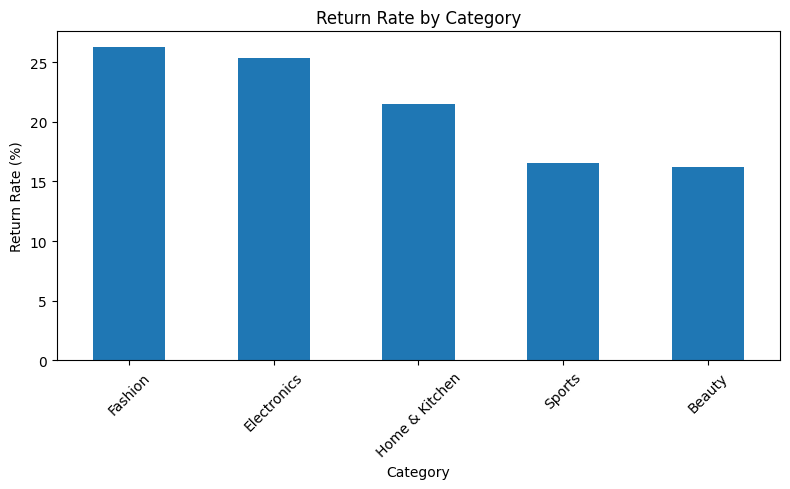

In [38]:
import matplotlib.pyplot as plt

# Bar Chart: Return Rate by Category

category_return_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# STEP 11: Return Rate by Discount

df["Discount_Group"] = pd.cut(
    df["Discount"],
    bins=[-1, 10, 20, 30, 40, 100],
    labels=["0-10", "11-20", "21-30", "31-40", "41+"]
)

discount_return_rate = (
    df.groupby("Discount_Group", observed=False)["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Return Rate by Discount:")
print(discount_return_rate)

Return Rate by Discount:
Discount_Group
0-10     19.515306
11-20    20.801527
21-30    21.700880
31-40    24.903475
41+      23.828125
Name: Returned, dtype: float64


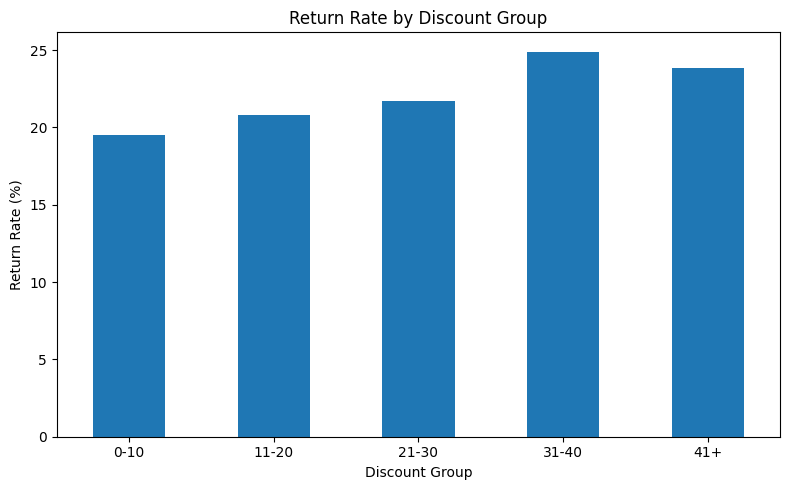

In [40]:
# STEP 12: Discount Return Rate Chart

import matplotlib.pyplot as plt

discount_return_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Return Rate by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# STEP 13: Return Rate by Delivery Days

df["Delivery_Group"] = pd.cut(
    df["Delivery_Days"],
    bins=[-1, 2, 4, 6, 8, float("inf")],
    labels=["0-2 Days", "3-4 Days", "5-6 Days", "7-8 Days", "9+ Days"]
)

delivery_return_rate = (
    df.groupby("Delivery_Group", observed=False)["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Return Rate by Delivery Days:")
print(delivery_return_rate)

Return Rate by Delivery Days:
Delivery_Group
0-2 Days    18.994413
3-4 Days    20.338983
5-6 Days    22.081656
7-8 Days    22.498119
9+ Days     25.791139
Name: Returned, dtype: float64


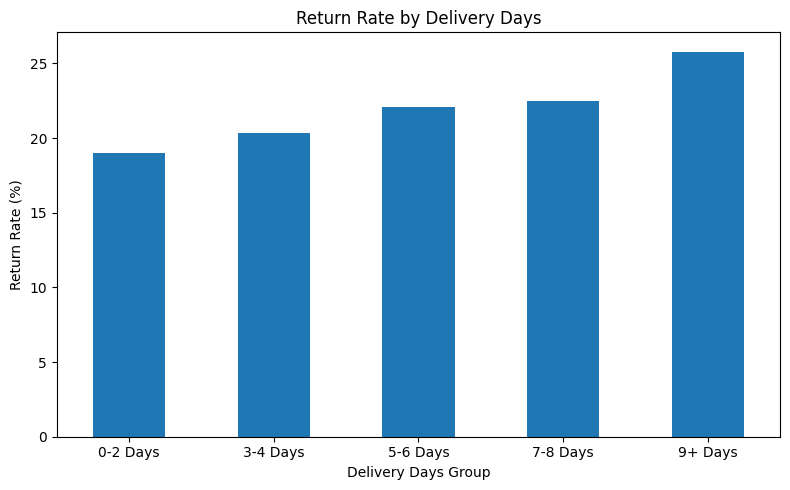

In [42]:
# STEP 14: Delivery Days Return Rate Chart

import matplotlib.pyplot as plt

delivery_return_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Return Rate by Delivery Days")
plt.xlabel("Delivery Days Group")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# STEP 15: Return Rate by Customer Rating

rating_return_rate = (
    df.groupby("Customer_Rating")["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Return Rate by Customer Rating:")
print(rating_return_rate)

Return Rate by Customer Rating:
Customer_Rating
1.1     50.000000
1.2      0.000000
1.3      0.000000
1.4      0.000000
1.5    100.000000
1.6      0.000000
1.7      0.000000
1.8     36.363636
1.9     27.272727
2.0     50.000000
2.1     35.714286
2.2     20.000000
2.3     35.135135
2.4     30.909091
2.5     18.644068
2.6     23.958333
2.7     13.186813
2.8     23.148148
2.9     18.253968
3.0     27.777778
3.1     25.000000
3.2     21.568627
3.3     18.981481
3.4     18.807339
3.5     22.580645
3.6     20.179372
3.7     18.454936
3.8     22.058824
3.9     18.803419
4.0     22.709163
4.1     19.313305
4.2     26.315789
4.3     22.815534
4.4     22.162162
4.5     24.861878
4.6     21.276596
4.7     22.834646
4.8     22.764228
4.9     27.192982
5.0     22.715405
Name: Returned, dtype: float64


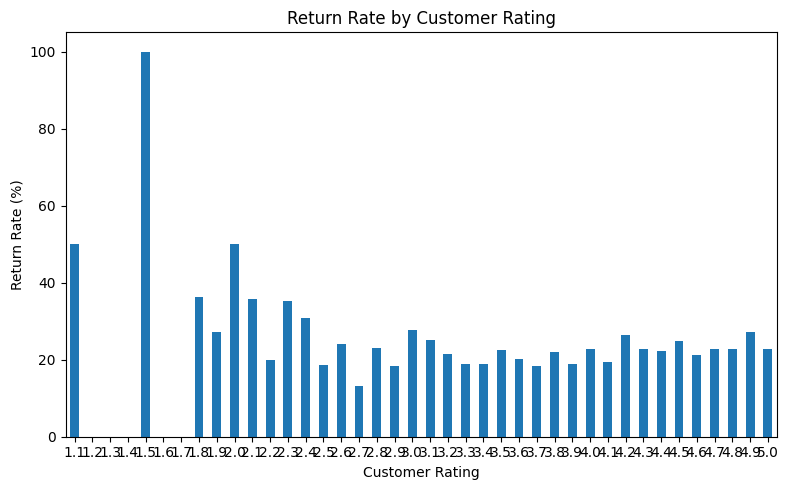

In [44]:
# STEP 16: Customer Rating Return Rate Chart

import matplotlib.pyplot as plt

rating_return_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Return Rate by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation Matrix:
                 Product_Price  Discount  Delivery_Days  Customer_Rating
Product_Price         1.000000  0.011472      -0.000111         0.020515
Discount              0.011472  1.000000      -0.030782        -0.006477
Delivery_Days        -0.000111 -0.030782       1.000000        -0.006794
Customer_Rating       0.020515 -0.006477      -0.006794         1.000000


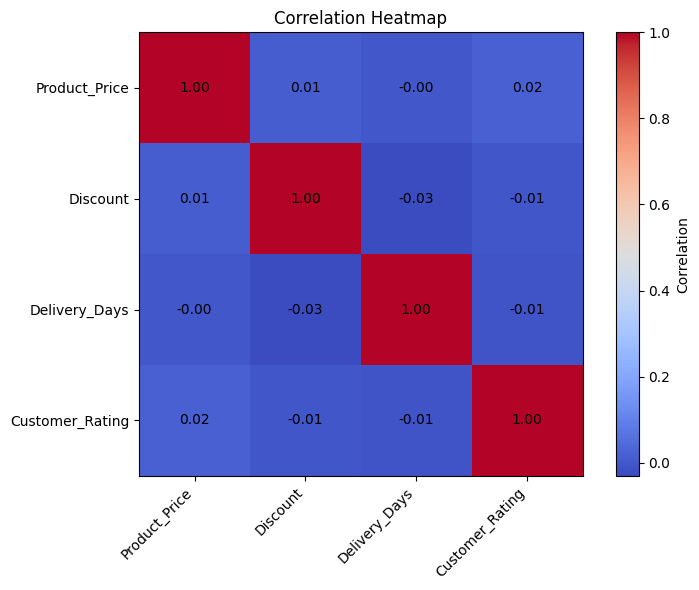

In [45]:
# STEP 17: Correlation Analysis

import matplotlib.pyplot as plt

# Select numerical columns
numerical_data = df[
    [
        "Product_Price",
        "Discount",
        "Delivery_Days",
        "Customer_Rating"
    ]
]

# Calculate correlation
correlation_matrix = numerical_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [46]:
# STEP 18: Summary of Return Analysis

total_orders = len(df)

returned_orders = (df["Returned"] == "Yes").sum()

return_percentage = (
    returned_orders / total_orders
) * 100

print("===== RETURN ANALYSIS SUMMARY =====")

print("Total Orders:", total_orders)

print("Returned Orders:", returned_orders)

print("Return Percentage:",
      round(return_percentage, 2), "%")

print("\n===== CATEGORY RETURN RATE =====")

print(category_return_rate)

print("\n===== DISCOUNT RETURN RATE =====")

print(discount_return_rate)

print("\n===== DELIVERY RETURN RATE =====")

print(delivery_return_rate)

print("\n===== RATING RETURN RATE =====")

print(rating_return_rate)

===== RETURN ANALYSIS SUMMARY =====
Total Orders: 5000
Returned Orders: 1108
Return Percentage: 22.16 %

===== CATEGORY RETURN RATE =====
Category
Fashion           26.269956
Electronics       25.311943
Home & Kitchen    21.456311
Sports            16.575342
Beauty            16.216216
Name: Returned, dtype: float64

===== DISCOUNT RETURN RATE =====
Discount_Group
0-10     19.515306
11-20    20.801527
21-30    21.700880
31-40    24.903475
41+      23.828125
Name: Returned, dtype: float64

===== DELIVERY RETURN RATE =====
Delivery_Group
0-2 Days    18.994413
3-4 Days    20.338983
5-6 Days    22.081656
7-8 Days    22.498119
9+ Days     25.791139
Name: Returned, dtype: float64

===== RATING RETURN RATE =====
Customer_Rating
1.1     50.000000
1.2      0.000000
1.3      0.000000
1.4      0.000000
1.5    100.000000
1.6      0.000000
1.7      0.000000
1.8     36.363636
1.9     27.272727
2.0     50.000000
2.1     35.714286
2.2     20.000000
2.3     35.135135
2.4     30.909091
2.5     18.644068

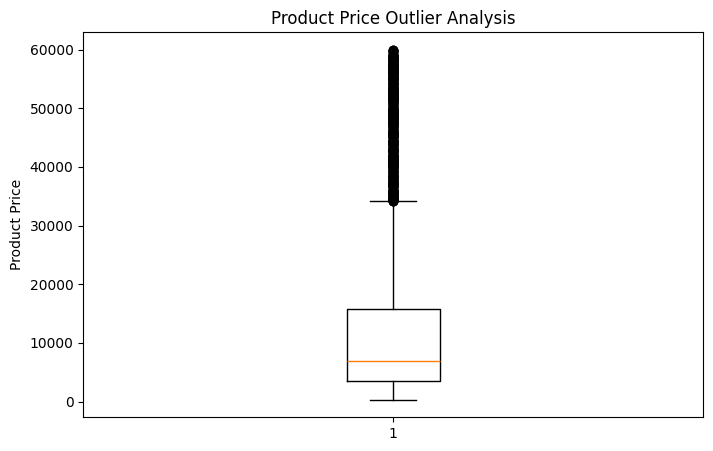

In [47]:
# STEP 19: Product Price Outlier Analysis

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(df["Product_Price"].dropna())

plt.title("Product Price Outlier Analysis")
plt.ylabel("Product Price")

plt.show()

In [48]:
# STEP 20: IQR Outlier Detection

Q1 = df["Product_Price"].quantile(0.25)
Q3 = df["Product_Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Product_Price"] < lower_limit) |
    (df["Product_Price"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Q1: 3547.85
Q3: 15804.897500000001
IQR: 12257.0475
Lower Limit: -14837.72125
Upper Limit: 34190.46875
Number of Outliers: 499


In [49]:
# STEP 21: Display Outlier Records

print("Outlier Records:")
outliers.head(10)

Outlier Records:


,Order_ID,Customer_ID,Category,Product_Price,Discount,Delivery_Days,Customer_Rating,Returned,Discount_Group,Delivery_Group
4,ORD100005,CUST1268,Electronics,52830.73,41.7,3.0,3.8,No,41+,3-4 Days
6,ORD100007,CUST1316,Electronics,47723.91,26.3,6.0,4.2,No,21-30,5-6 Days
13,ORD100014,CUST1502,Electronics,39942.78,33.1,8.0,3.7,No,31-40,7-8 Days
31,ORD100032,CUST1903,Electronics,34285.90,45.2,9.0,3.3,No,41+,9+ Days
32,ORD100033,CUST1886,Electronics,36042.91,22.4,11.0,3.8,No,21-30,9+ Days
37,ORD100038,CUST1340,Electronics,58340.04,61.3,9.0,2.7,No,41+,9+ Days
40,ORD100041,CUST1099,Electronics,46921.66,0.0,4.0,4.8,No,0-10,3-4 Days
58,ORD100059,CUST1087,Electronics,35699.42,26.4,5.0,2.0,No,21-30,5-6 Days
68,ORD100069,CUST1752,Electronics,55629.47,18.9,4.0,4.6,No,11-20,3-4 Days
71,ORD100072,CUST1101,Electronics,45736.50,34.7,5.0,4.9,Yes,31-40,5-6 Days


In [50]:
# STEP 22: Outlier Return Rate Analysis

df["Price_Outlier"] = (
    (df["Product_Price"] < lower_limit) |
    (df["Product_Price"] > upper_limit)
)

outlier_return_rate = (
    df.groupby("Price_Outlier")["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Return Rate: Normal vs Outlier Products")
print(outlier_return_rate)

Return Rate: Normal vs Outlier Products
Price_Outlier
False    21.684070
True     26.452906
Name: Returned, dtype: float64


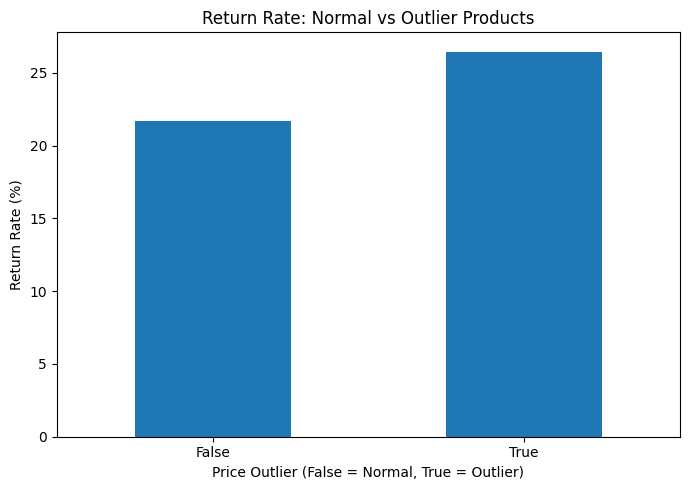

In [51]:
# STEP 23: Outlier Return Rate Chart

import matplotlib.pyplot as plt

outlier_return_rate.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Return Rate: Normal vs Outlier Products")
plt.xlabel("Price Outlier (False = Normal, True = Outlier)")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
# STEP 24: Save Cleaned Dataset

df.to_csv(
    "/content/cleaned_ecommerce_returns.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [53]:
# STEP 25: Final Analysis Findings

print("===== FINAL ANALYSIS FINDINGS =====")

print("\n1. Highest Return Rate by Category:")
print(category_return_rate.idxmax(), ":", round(category_return_rate.max(), 2), "%")

print("\n2. Highest Return Rate by Discount:")
print(discount_return_rate.idxmax(), ":", round(discount_return_rate.max(), 2), "%")

print("\n3. Highest Return Rate by Delivery Days:")
print(delivery_return_rate.idxmax(), ":", round(delivery_return_rate.max(), 2), "%")

print("\n4. Highest Return Rate by Customer Rating:")
print(rating_return_rate.idxmax(), ":", round(rating_return_rate.max(), 2), "%")

===== FINAL ANALYSIS FINDINGS =====

1. Highest Return Rate by Category:
Fashion : 26.27 %

2. Highest Return Rate by Discount:
31-40 : 24.9 %

3. Highest Return Rate by Delivery Days:
9+ Days : 25.79 %

4. Highest Return Rate by Customer Rating:
1.5 : 100.0 %


# E-commerce Return Rate Investigation

## Project Conclusion

This project analyzed e-commerce order data to understand the factors affecting product returns.

### Key Findings

1. The overall return rate was calculated using the total number of orders and returned orders.
2. Return rates were compared across different product categories.
3. The relationship between discount ranges and return rates was analyzed.
4. Delivery time groups were compared to understand their return rates.
5. Customer ratings were analyzed to identify differences in return rates.
6. Product price outliers were identified using the IQR method.

### Data Cleaning

- Duplicate records were removed.
- Missing numerical values were handled using the median.
- Additional groups were created for discount and delivery days.

### Conclusion

The analysis helps identify patterns in e-commerce product returns. These findings can help businesses investigate product categories, discounts, delivery times, and customer satisfaction to improve their return management process.

# E-commerce Return Rate Investigation

## 1. Project Introduction

This project focuses on analyzing e-commerce order data to understand product return patterns.

The analysis examines product categories, discounts, delivery times, customer ratings, and product prices to identify factors associated with product returns.

## 2. Project Objective

- Calculate the overall product return rate.
- Analyze return rates across product categories.
- Study the relationship between discounts and returns.
- Examine delivery time and customer rating patterns.
- Identify product price outliers using the IQR method.

## 3. Tools and Technologies

- Python
- Pandas
- Matplotlib
- Google Colab
- CSV Dataset
-

## 4. Data Cleaning and Preprocessing

The dataset was cleaned before performing the analysis.

### Data Cleaning Steps

1. Loaded the e-commerce dataset using Pandas.
2. Checked the dataset shape and column names.
3. Identified and removed duplicate records.
4. Handled missing values in Product_Price, Delivery_Days, and Customer_Rating using the median.
5. Created discount groups to compare return rates.
6. Created delivery day groups to analyze delivery-related return patterns.
7. Identified product price outliers using the IQR method.

### Dataset Details

- Original Records: 5,005
- Records After Removing Duplicates: 5,000
- Number of Columns: 8
- Missing numerical values were handled using median imputation.
-

## 5. Overall Return Rate Analysis

The dataset contains 5,000 orders after removing duplicate records.

### Results

- Total Orders: 5,000
- Returned Orders: 1,108
- Overall Return Rate: 22.16%

### Interpretation

The analysis shows that 22.16% of the orders in the cleaned dataset were returned. This result provides an overview of the return situation and helps businesses investigate the reasons behind product returns.

## 6. Category Return Rate Analysis

The return rate was calculated for each product category.

### Analysis

The return rates of different product categories were compared to identify categories with higher return percentages.

A bar chart was created to visualize the return rate for each category.

### Interpretation

The category with the highest return rate can be identified from the analysis. This information may help businesses investigate product quality, customer expectations, and category-specific return reasons.

## 7. Discount Return Rate Analysis

The relationship between discount percentages and product return rates was analyzed.

### Discount Groups

The discounts were divided into the following groups:

- 0-10%
- 11-20%
- 21-30%
- 31-40%
- 41% and above

### Results

| Discount Group | Return Rate |
|---|---|
| 0-10% | 19.52% |
| 11-20% | 20.80% |
| 21-30% | 21.70% |
| 31-40% | 24.90% |
| 41% and above | 23.83% |

### Interpretation

The 31-40% discount group had the highest observed return rate in this dataset, at 24.90%. This is an observed pattern and does not by itself prove that discounts caused returns.

## 8. Delivery Days Return Rate Analysis

The relationship between delivery time and product return rates was analyzed.

### Delivery Groups

The delivery days were divided into the following groups:

- 0-2 Days
- 3-4 Days
- 5-6 Days
- 7-8 Days
- 9+ Days

### Analysis

The return rate was calculated for each delivery time group. A bar chart was created to compare the return rates.

### Interpretation

The delivery group with the highest return rate can be identified from the analysis. This information may help businesses investigate delivery delays and customer satisfaction.

## 9. Customer Rating Return Rate Analysis

The relationship between customer ratings and product return rates was analyzed.

### Analysis

The return rate was calculated for each customer rating. This helps identify whether return patterns differ between products with different customer ratings.

A comparison of customer ratings and return rates was performed using Python and Pandas.

### Interpretation

The rating group with the highest return rate can be identified from the analysis. Customer ratings may help businesses investigate customer satisfaction and potential product issues.

## 10. Correlation Analysis

Correlation analysis was performed to understand the relationships between numerical variables in the dataset.

### Numerical Variables

- Product Price
- Discount
- Delivery Days
- Customer Rating

A correlation matrix and heatmap were created using Python.

### Interpretation

The correlation heatmap helps visualize the strength and direction of relationships between numerical variables.

- A positive correlation indicates that two variables tend to increase together.
- A negative correlation indicates that one variable tends to increase when the other decreases.
- A correlation close to zero indicates a weak linear relationship.

Correlation does not prove that one variable causes another.

## 11. Product Price Outlier Analysis

The Interquartile Range (IQR) method was used to identify unusual product prices.

### Method

- Q1 represents the 25th percentile.
- Q3 represents the 75th percentile.
- IQR is calculated as Q3 - Q1.
- The lower and upper limits were calculated using the IQR method.

Products outside these limits were identified as potential outliers.

### Analysis

A boxplot was created to visualize the distribution of product prices and identify potential outliers.

The return rate of normal-priced products and outlier products was also compared.

### Interpretation

Outlier analysis helps identify unusually priced products. These products can be investigated further to understand whether their return patterns differ from other products.

## 12. Final Conclusion

This project investigated e-commerce product return patterns using Python, Pandas, and Matplotlib.

The analysis included product categories, discount ranges, delivery days, customer ratings, and product price outliers.

The overall return rate was 22.16%, based on 1,108 returned orders out of 5,000 orders.

The analysis provides useful information for understanding return patterns and identifying areas that may require further investigation.

## 13. Recommendations

1. Investigate categories with higher return rates.
2. Review products with unusual return patterns.
3. Study customer feedback and ratings to identify potential product issues.
4. Analyze delivery performance and customer satisfaction.
5. Monitor return rates across different discount groups.
6. Use data analysis to support improvements in return management.

## 14. Future Scope

- Build a machine learning model to predict product returns.
- Analyze customer feedback using sentiment analysis.
- Create an interactive dashboard using Power BI or Tableau.
- Investigate the main reasons for product returns.
-